# Financial Resilience and Short-Term Financial Stress Analysis

This project investigates the key drivers of financial vulnerability using a Debt-to-Income (DTI) framework. 

We aim to:
- Identify structural factors associated with higher financial burden
- Examine demographic and housing-related disparities
- Quantify the impact of external financial shocks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('personal_finance_dataset(without dictionary file).xlsx')

In [2]:
df

,PAGEMIEG,PATTCRU,PATTSITC,PATTSKP,PEDUCMIE,PEFATINC,PFMTYPG,PFTENUR,PLFFPTME,PNBEARG,PPVRES,PWAPRVAL,PWASTDEP,PWATFS,PWDPRMOR,PWDSLOAN,PWDSTCRD,PWDSTLOC,PWNETWPG
0,6,4,3,2,4,115525,4,1,3,2,35,1000000,16000,90000,0,0,0,0,3713000
1,7,4,3,2,9,121300,2,1,3,9,47,625000,2900,15500,0,0,0,145000,1740900
2,5,4,3,2,4,19175,2,1,3,0,48,875000,5000,50000,0,0,0,40000,3672500
3,6,3,3,2,4,147425,2,2,2,2,35,500000,1050,11500,180000,0,18500,10000,2809050
4,4,4,3,2,3,56750,1,3,1,1,35,0,0,0,0,0,0,0,471900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16236,4,4,1,2,4,47175,1,3,1,1,59,0,7000,10500,0,0,0,0,96850
16237,6,4,2,2,2,121925,2,2,1,2,46,700000,280000,100000,28000,0,0,0,1989000
16238,2,4,2,2,4,124425,3,2,1,2,24,250000,8250,9500,82500,30000,0,850,240100
16239,3,4,3,1,3,67625,1,3,1,1,24,0,1550,2100,0,2500,450,0,23750


In [3]:
# Check for missing values
print(df.isnull().sum())

PAGEMIEG    0
PATTCRU     0
PATTSITC    0
PATTSKP     0
PEDUCMIE    0
PEFATINC    0
PFMTYPG     0
PFTENUR     0
PLFFPTME    0
PNBEARG     0
PPVRES      0
PWAPRVAL    0
PWASTDEP    0
PWATFS      0
PWDPRMOR    0
PWDSLOAN    0
PWDSTCRD    0
PWDSTLOC    0
PWNETWPG    0
dtype: int64


In [4]:
print(df.columns)

Index(['PAGEMIEG', 'PATTCRU', 'PATTSITC', 'PATTSKP', 'PEDUCMIE', 'PEFATINC',
       'PFMTYPG', 'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PPVRES', 'PWAPRVAL',
       'PWASTDEP', 'PWATFS', 'PWDPRMOR', 'PWDSLOAN', 'PWDSTCRD', 'PWDSTLOC',
       'PWNETWPG'],
      dtype='object')


## Defining Financial Resilience

We measure short-term financial resilience using the Debt-to-Income Ratio (DTI):

DTI = Total Debt / Annual After-Tax Income

Total Debt includes:
- Mortgage debt
- Credit card debt
- Student and personal loans
- Other liabilities

A higher DTI indicates a greater financial burden relative to income and lower financial resilience.

In [5]:
# Calculate total debt by summing the individual debt columns
df['total_debt'] = df['PWDSLOAN'] + df['PWDSTCRD'] + df['PWDPRMOR'] + df['PWDSTLOC']

# Calculate Debt-to-Income Ratio (DTI)
df['DTI'] = df['total_debt'] / df['PEFATINC']

# Display the first few rows to check the DTI calculation
df[['PWDSLOAN', 'PWDSTCRD', 'PWDPRMOR', 'PWDSTLOC', 'PEFATINC', 'total_debt', 'DTI']]

,PWDSLOAN,PWDSTCRD,PWDPRMOR,PWDSTLOC,PEFATINC,total_debt,DTI
0,0,0,0,0,115525,0,0.000000
1,0,0,0,145000,121300,145000,1.195383
2,0,0,0,40000,19175,40000,2.086050
3,0,18500,180000,10000,147425,208500,1.414278
4,0,0,0,0,56750,0,0.000000
...,...,...,...,...,...,...,...
16236,0,0,0,0,47175,0,0.000000
16237,0,0,28000,0,121925,28000,0.229649
16238,30000,0,82500,850,124425,113350,0.910991
16239,2500,450,0,0,67625,2950,0.043623


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


if not hasattr(sns, "histplot"):
    def histplot(data, kde=False, bins=30, ax=None, **kwargs):
        """
        Minimal seaborn.histplot compatibility for old seaborn versions.
        Supports: data (1D), kde=True/False, bins, ax.
        """
        if ax is None:
            ax = plt.gca()

        # histogram
        sns.distplot(data, kde=kde, bins=bins, ax=ax)
        return ax

    sns.histplot = histplot


In [7]:
# Check the minimum and maximum DTI values
print(df['DTI'].min(), df['DTI'].max())

-50.0 inf


## Data Cleaning

To ensure analytical accuracy:

- Removed invalid or negative DTI values
- Removed infinite DTI cases (zero income)
- Filtered extreme outliers for visualization clarity

This step ensures that the analysis reflects realistic financial conditions.

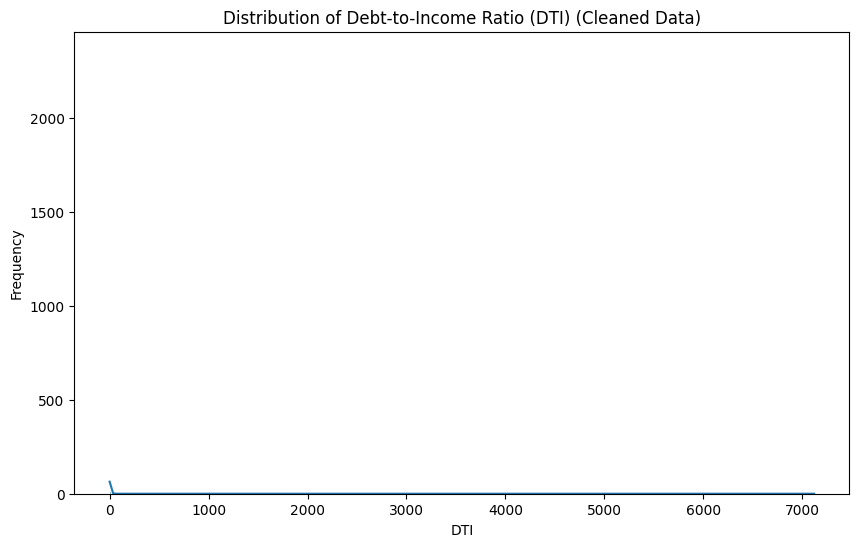

In [8]:
# Remove rows where DTI is negative or infinite
df_cleaned = df[(df['DTI'] > 0) & (df['DTI'] != np.inf)]

# Plot the distribution of valid DTI values
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['DTI'], kde=True)
plt.title('Distribution of Debt-to-Income Ratio (DTI) (Cleaned Data)')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

In [9]:
# Recalculate the DTI column (ensure debt and income columns exist)
df['DTI'] = (df['PWDSLOAN'] + df['PWDSTCRD'] + df['PWDPRMOR'] + df['PWDSTLOC']) / df['PEFATINC']

# Display the first few rows to check the DTI calculation
print(df[['PWDSLOAN', 'PWDSTCRD', 'PWDPRMOR', 'PWDSTLOC', 'PEFATINC', 'DTI']])
import numpy as np  # Import NumPy

       PWDSLOAN  PWDSTCRD  PWDPRMOR  PWDSTLOC  PEFATINC       DTI
0             0         0         0         0    115525  0.000000
1             0         0         0    145000    121300  1.195383
2             0         0         0     40000     19175  2.086050
3             0     18500    180000     10000    147425  1.414278
4             0         0         0         0     56750  0.000000
...         ...       ...       ...       ...       ...       ...
16236         0         0         0         0     47175  0.000000
16237         0         0     28000         0    121925  0.229649
16238     30000         0     82500       850    124425  0.910991
16239      2500       450         0         0     67625  0.043623
16240         0      6750    170000      6500    152350  1.202822

[16241 rows x 6 columns]


In [10]:
# Remove rows where DTI is negative or infinite
df_cleaned = df[(df['DTI'] > 0) & (df['DTI'] != np.inf)]

# Check if the cleaned data has valid DTI values
print(df_cleaned['DTI'])

1        1.195383
2        2.086050
3        1.414278
5        0.194986
7        0.053797
           ...   
16235    1.953488
16237    0.229649
16238    0.910991
16239    0.043623
16240    1.202822
Name: DTI, Length: 9368, dtype: float64


In [11]:
# Check the minimum and maximum values of the cleaned DTI
print(df_cleaned['DTI'].min(), df_cleaned['DTI'].max())

1.819505094614265e-05 7121.0


## Distribution of Financial Resilience

We examine the distribution of DTI across households to understand overall financial burden patterns.

This allows us to identify:
- The typical financial burden level
- Presence of extreme financial distress
- Long-tail risk distribution

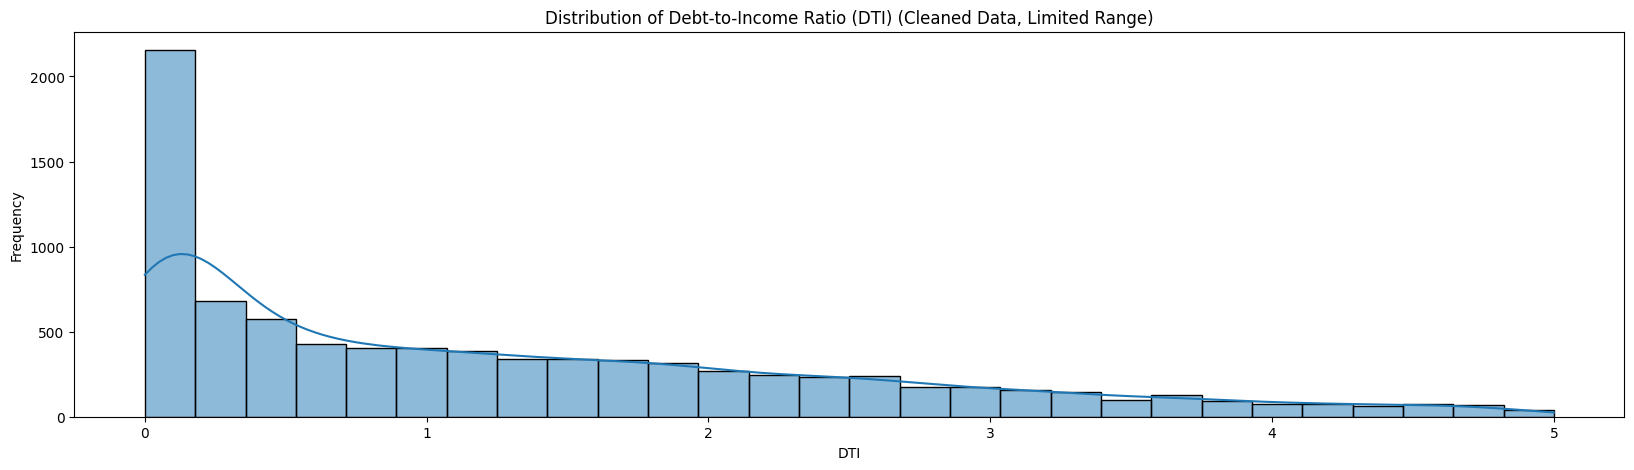

In [12]:
# Limit the DTI values to a maximum of 10 for better visualization
plt.figure(figsize=(20, 5))
sns.histplot(df_cleaned[df_cleaned['DTI'] <= 5]['DTI'], kde=True)
plt.title('Distribution of Debt-to-Income Ratio (DTI) (Cleaned Data, Limited Range)')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

In [13]:
# Check how many rows are left after cleaning the data
print(df_cleaned.shape)

(9368, 21)


In [14]:
print(df.columns)


Index(['PAGEMIEG', 'PATTCRU', 'PATTSITC', 'PATTSKP', 'PEDUCMIE', 'PEFATINC',
       'PFMTYPG', 'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PPVRES', 'PWAPRVAL',
       'PWASTDEP', 'PWATFS', 'PWDPRMOR', 'PWDSLOAN', 'PWDSTCRD', 'PWDSTLOC',
       'PWNETWPG', 'total_debt', 'DTI'],
      dtype='object')


## Identifying Key Drivers of Financial Stress

We apply regression analysis to identify which financial and demographic factors most strongly predict DTI levels.

This helps answer:

Which structural factors are most associated with reduced financial resilience?

R2 = 0.39629078317454147
MAE = 0.3628711190610473

Top 15 Variables:
      Variable  Coefficient  Abs_Coefficient
0    PFTENUR_2     0.803065         0.803065
1   PAGEMIEG_7    -0.700065         0.700065
2    PNBEARG_3    -0.565837         0.565837
3    PNBEARG_2    -0.430874         0.430874
4    PNBEARG_1    -0.334220         0.334220
5   PAGEMIEG_5    -0.293198         0.293198
6   PAGEMIEG_4    -0.223382         0.223382
7    PFTENUR_3    -0.190008         0.190008
8   PLFFPTME_2     0.169846         0.169846
9   PAGEMIEG_3    -0.143677         0.143677
10  PEDUCMIE_4     0.118201         0.118201
11   PFMTYPG_2    -0.117000         0.117000
12  PEDUCMIE_2     0.104920         0.104920
13  PLFFPTME_3     0.101008         0.101008
14  PAGEMIEG_2    -0.097301         0.097301


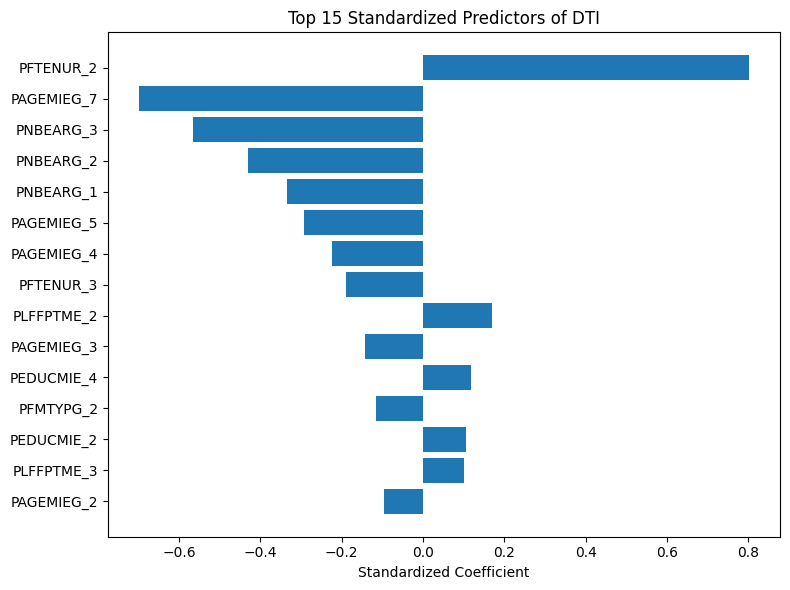

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
data = df_cleaned.copy()
categorical_cols = ['PAGEMIEG', 'PEDUCMIE', 'PFMTYPG',
                    'PFTENUR', 'PLFFPTME', 'PNBEARG']
for col in categorical_cols:
    data = data[(data[col] != 9) & (data[col] != 6)]
    
data['y'] = np.log1p(data['DTI'])

features = ['PAGEMIEG', 'PEDUCMIE', 'PFMTYPG',
            'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PWASTDEP']
X = data[features].copy()
y = data['y']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("\nTop 15 Variables:")
print(coef_df.head(15))

import matplotlib.pyplot as plt

top15 = coef_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top15['Variable'], top15['Coefficient'])
plt.gca().invert_yaxis()
plt.title("Top 15 Standardized Predictors of DTI")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

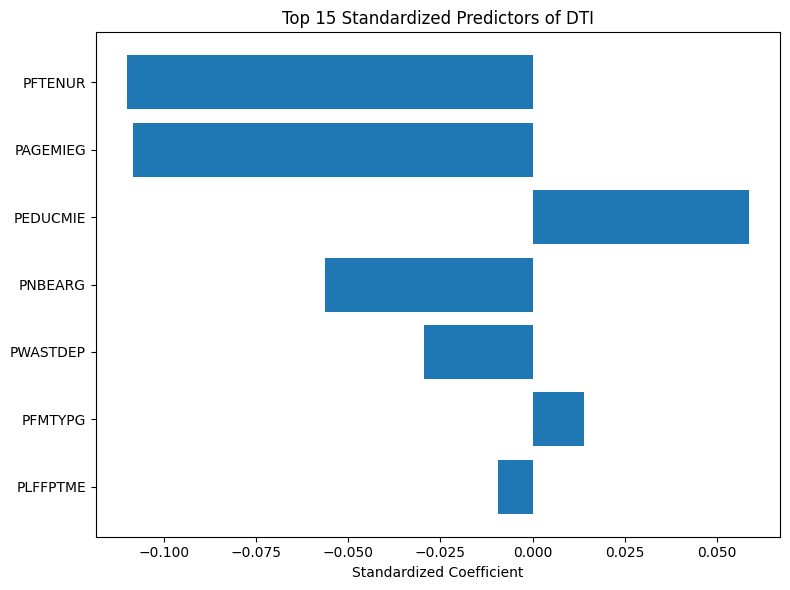

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
data['y'] = np.log1p(data['DTI'])
features = ['PAGEMIEG', 'PEDUCMIE', 'PFMTYPG',
            'PFTENUR', 'PLFFPTME', 'PNBEARG', 'PWASTDEP']

X = data[features].copy()
y = data['y']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

coef_df.head(15)

import matplotlib.pyplot as plt

top15 = coef_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top15['Variable'], top15['Coefficient'])
plt.gca().invert_yaxis()
plt.title("Top 15 Standardized Predictors of DTI")
plt.xlabel("Standardized Coefficient")
plt.tight_layout()
plt.show()

## Deep Dive: Housing Tenure

Housing tenure (renting vs owning) emerged as a key driver of financial vulnerability.

We further examine how DTI varies across housing groups to understand structural differences in financial burden.

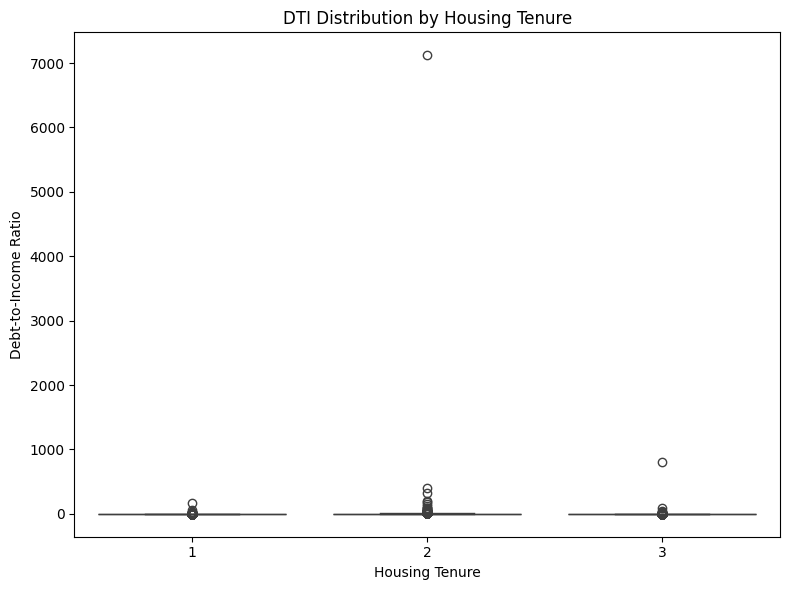

,count,mean,std,min,25%,50%,75%,max
PFTENUR,,,,,,,,
1,1922.0,0.682879,4.197680,0.000122,0.031573,0.128235,0.499785,160.0
2,5820.0,4.170367,93.733918,0.000018,1.056472,1.919339,3.174610,7121.0
3,1626.0,0.972848,20.001989,0.000141,0.043168,0.144097,0.397381,800.0


In [17]:
## Deep Dive 1: Housing Tenure and Financial Burden
df_cleaned['PFTENUR'].value_counts()
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(x='PFTENUR', y='DTI', data=df_cleaned)

plt.title("DTI Distribution by Housing Tenure")
plt.xlabel("Housing Tenure")
plt.ylabel("Debt-to-Income Ratio")
plt.tight_layout()
plt.show()

df_cleaned.groupby('PFTENUR')['DTI'].describe()

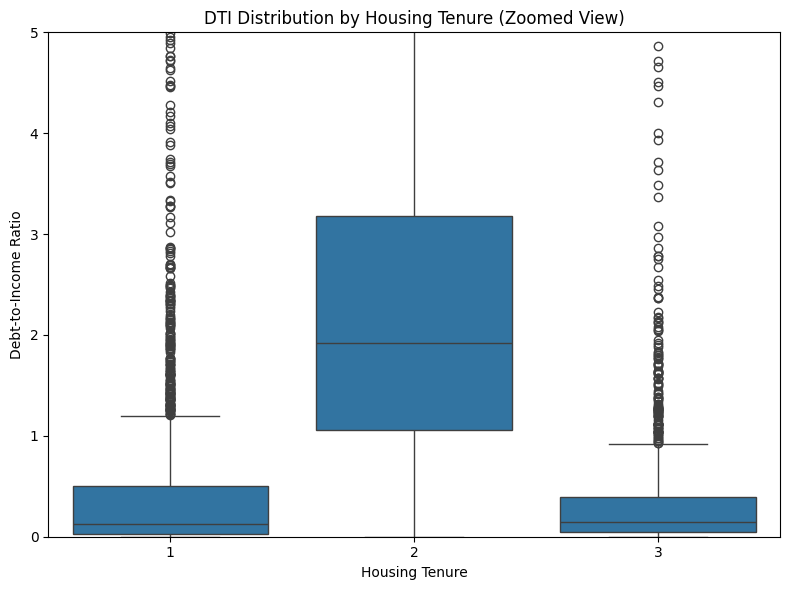

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(x='PFTENUR', y='DTI', data=df_cleaned)

plt.ylim(0, 5)  # only shows the range of 0-5
plt.title("DTI Distribution by Housing Tenure (Zoomed View)")
plt.xlabel("Housing Tenure")
plt.ylabel("Debt-to-Income Ratio")
plt.tight_layout()
plt.show()

## Deep Dive: Age Effects

Age group analysis reveals structural differences in financial burden across life stages.

We focus particularly on the 80+ population to understand how late-life financial dynamics differ from working-age households.

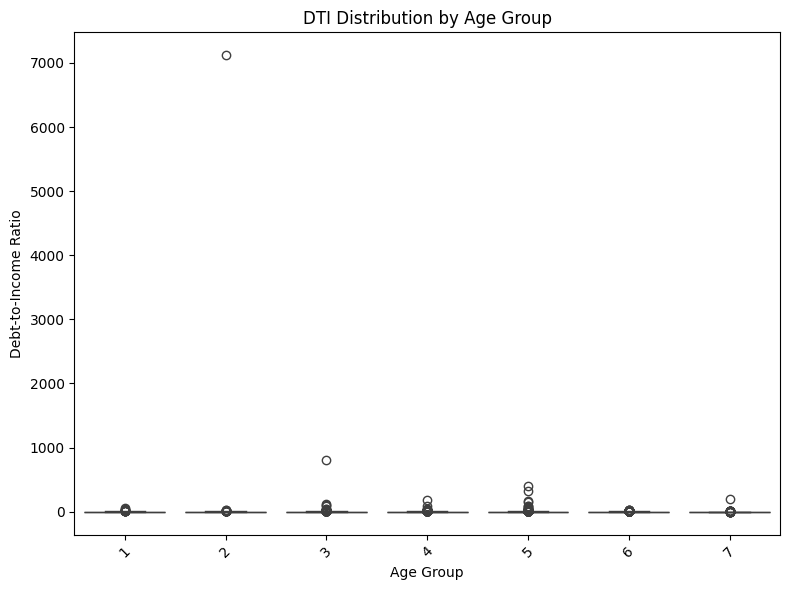

,count,mean,std,min,25%,50%,75%,max
is_80_plus,,,,,,,,
0,9101.0,2.935877,75.442525,0.000018,0.227625,1.121563,2.464332,7121.000000
1,267.0,1.672129,12.434042,0.000122,0.036969,0.215297,1.046281,202.197802


In [19]:
## Deep Dive 2: Age and Financial Fragility
df_cleaned['PAGEMIEG'].value_counts()
plt.figure(figsize=(8,6))
sns.boxplot(x='PAGEMIEG', y='DTI', data=df_cleaned)

plt.title("DTI Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Debt-to-Income Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df_cleaned = df_cleaned.copy()
df_cleaned['is_80_plus'] = (df_cleaned['PAGEMIEG'] == 7).astype(int)  

df_cleaned.groupby('is_80_plus')['DTI'].describe()



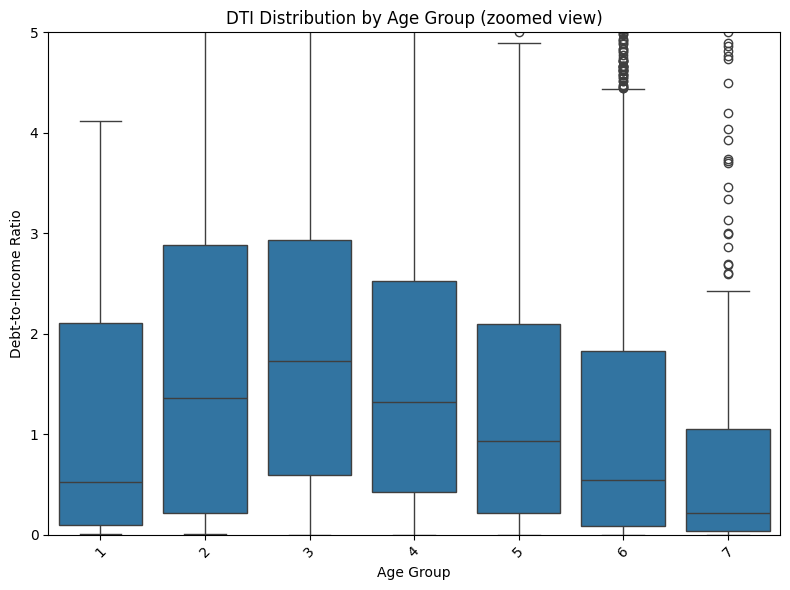

,count,mean,std,min,25%,50%,75%,max
is_80_plus,,,,,,,,
0,9101.0,2.935877,75.442525,0.000018,0.227625,1.121563,2.464332,7121.000000
1,267.0,1.672129,12.434042,0.000122,0.036969,0.215297,1.046281,202.197802


In [20]:
## Deep Dive 2: Age and Financial Fragility
df_cleaned['PAGEMIEG'].value_counts()
plt.figure(figsize=(8,6))
sns.boxplot(x='PAGEMIEG', y='DTI', data=df_cleaned)
plt.ylim(0, 5) # only show the range of 0-5
plt.title("DTI Distribution by Age Group (zoomed view)")
plt.xlabel("Age Group")
plt.ylabel("Debt-to-Income Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
df_cleaned = df_cleaned.copy()
df_cleaned['is_80_plus'] = (df_cleaned['PAGEMIEG'] == 7).astype(int)  

df_cleaned.groupby('is_80_plus')['DTI'].describe()

## Shock Simulation: Rent Increase Scenario

We simulate a 10% rent increase to assess its impact on financial resilience.

This scenario allows us to quantify how modest housing cost increases may push households into financial risk.

High Risk Rate Before Shock: 0.3433
High Risk Rate After Shock: 0.3851
Increase: 0.0417

Risk by Home Ownership:
         HighRisk_before  HighRisk_after
PFTENUR                                 
1               0.051220        0.062195
2               0.488699        0.546752
3               0.028789        0.033870

Risk by Number of Earners:
         HighRisk_before  HighRisk_after
PNBEARG                                 
0               0.260062        0.287926
1               0.355545        0.387369
2               0.380747        0.430316
3               0.249540        0.293738

Increase by Home Ownership (After - Before):
         HighRisk_before  HighRisk_after  Increase
PFTENUR                                           
2               0.488699        0.546752  0.058054
1               0.051220        0.062195  0.010976
3               0.028789        0.033870  0.005080


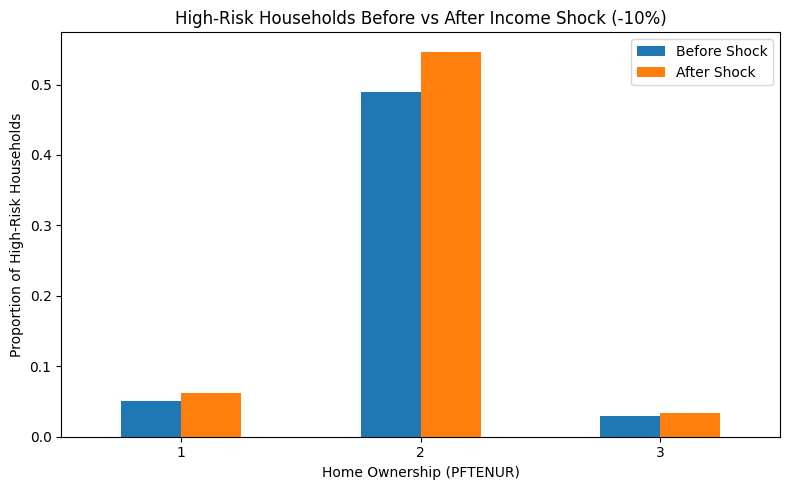

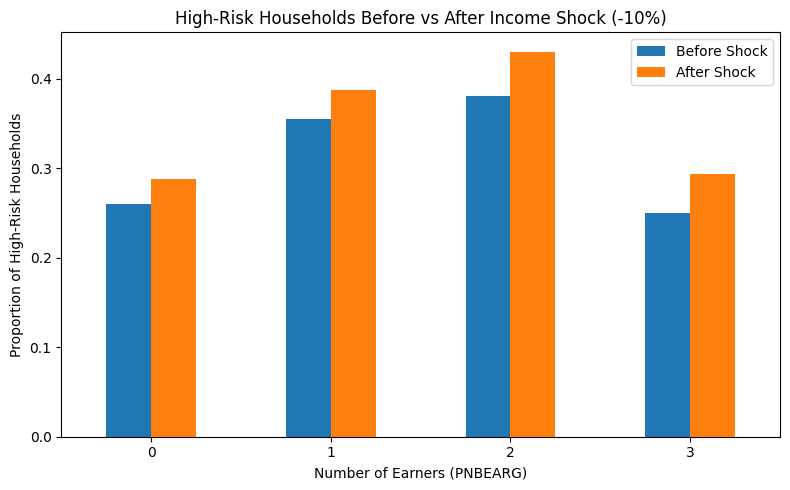

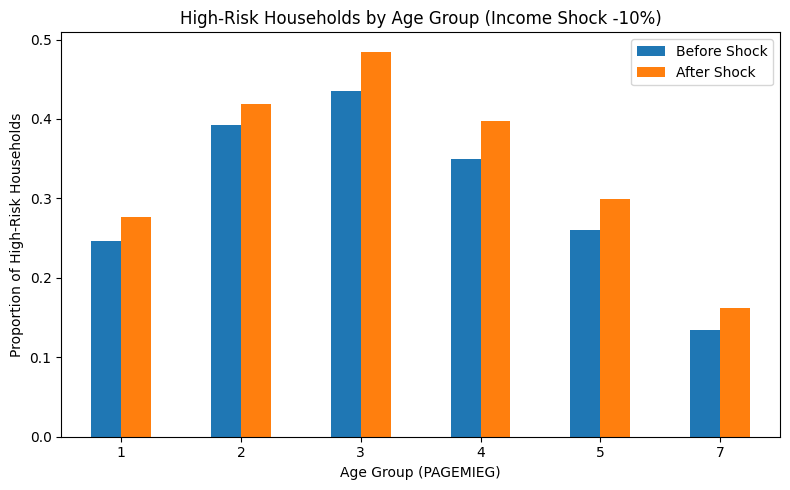

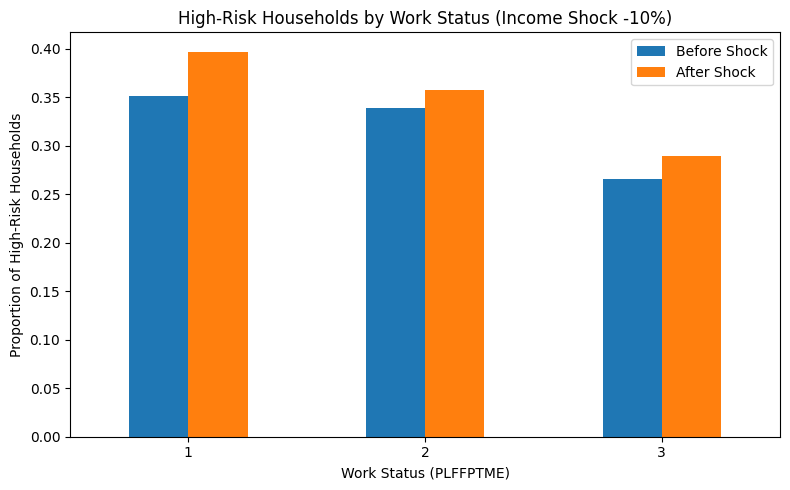

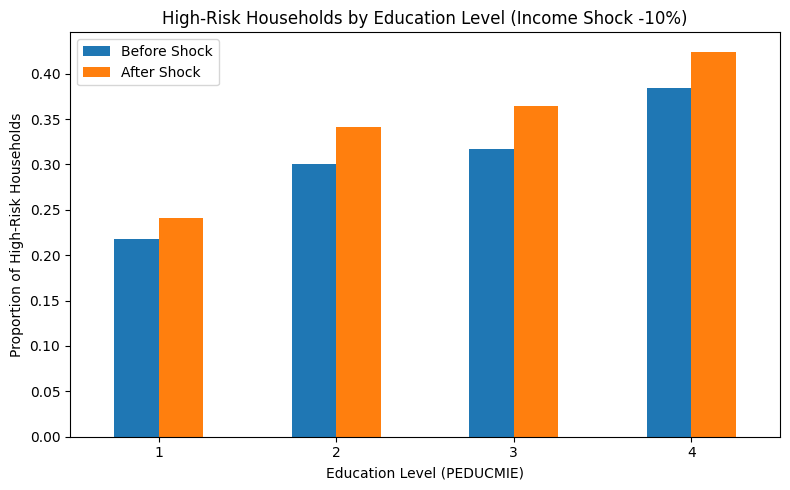

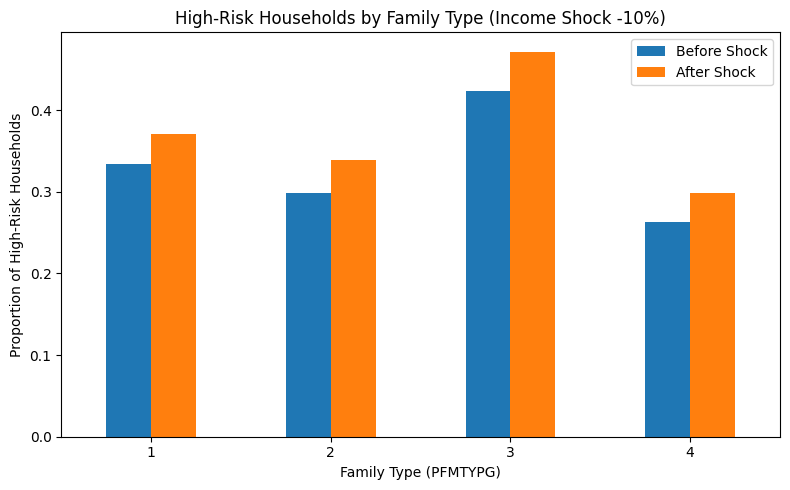

,HighRisk_before,HighRisk_after
PFMTYPG,,
1,0.333584,0.370482
2,0.298197,0.339112
3,0.423321,0.471869
4,0.263415,0.299187


In [21]:
#shock simulation
data['DTI_shock'] = data['total_debt'] / (data['PEFATINC'] * 0.9)

threshold = 2
data['HighRisk_before'] = (data['DTI'] > threshold).astype(int)
data['HighRisk_after'] = (data['DTI_shock'] > threshold).astype(int)

before_rate = data['HighRisk_before'].mean()
after_rate = data['HighRisk_after'].mean()

print("High Risk Rate Before Shock:", round(before_rate,4))
print("High Risk Rate After Shock:", round(after_rate,4))
print("Increase:", round(after_rate - before_rate,4))

risk_by_home = data.groupby('PFTENUR')[['HighRisk_before','HighRisk_after']].mean().sort_index()
risk_by_earner = data.groupby('PNBEARG')[['HighRisk_before','HighRisk_after']].mean().sort_index()

print("\nRisk by Home Ownership:")
print(risk_by_home)

print("\nRisk by Number of Earners:")
print(risk_by_earner)

#increase by group
risk_by_home['Increase'] = risk_by_home['HighRisk_after'] - risk_by_home['HighRisk_before']
print("\nIncrease by Home Ownership (After - Before):")
print(risk_by_home.sort_values('Increase', ascending=False))

import matplotlib.pyplot as plt

def plot_shock_by_group(df, group_col, title, xlabel):
    tbl = df.groupby(group_col)[['HighRisk_before','HighRisk_after']].mean().sort_index()
    ax = tbl.plot(kind='bar', figsize=(8,5))
    plt.title(title)
    plt.ylabel("Proportion of High-Risk Households")
    plt.xlabel(xlabel)
    plt.xticks(rotation=0)
    plt.legend(["Before Shock", "After Shock"])
    plt.tight_layout()
    plt.show()
    return tbl
# Home Ownership
plot_shock_by_group(data, 'PFTENUR',
                    "High-Risk Households Before vs After Income Shock (-10%)",
                    "Home Ownership (PFTENUR)")

# Number of Earners
plot_shock_by_group(data, 'PNBEARG',
                    "High-Risk Households Before vs After Income Shock (-10%)",
                    "Number of Earners (PNBEARG)")

# Age Group
plot_shock_by_group(data, 'PAGEMIEG',
                    "High-Risk Households by Age Group (Income Shock -10%)",
                    "Age Group (PAGEMIEG)")

# Work Status 2022
plot_shock_by_group(data, 'PLFFPTME',
                    "High-Risk Households by Work Status (Income Shock -10%)",
                    "Work Status (PLFFPTME)")

# Education Level
plot_shock_by_group(data, 'PEDUCMIE',
                    "High-Risk Households by Education Level (Income Shock -10%)",
                    "Education Level (PEDUCMIE)")

# Family Type
plot_shock_by_group(data, 'PFMTYPG',
                    "High-Risk Households by Family Type (Income Shock -10%)",
                    "Family Type (PFMTYPG)")

                  HighRisk_before  HighRisk_after  Increase
deposit_quartile                                           
0                        0.300633        0.337342  0.036709
1                        0.379265        0.421916  0.042651
2                        0.376648        0.422473  0.045825
3                        0.316523        0.358328  0.041805


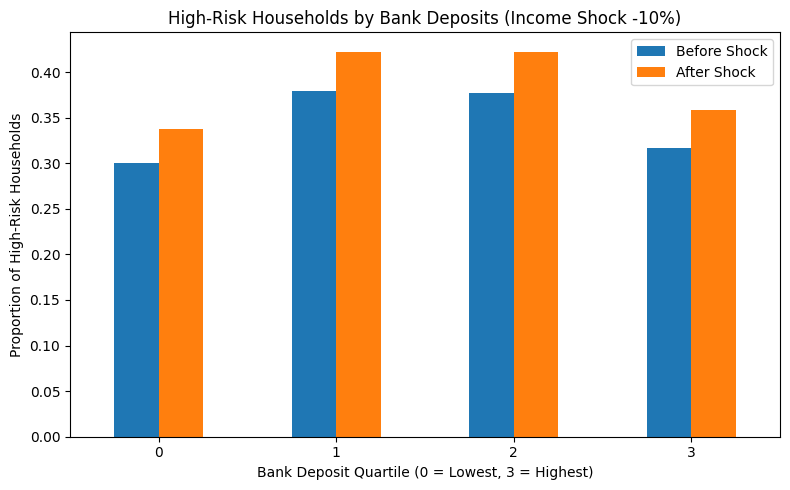

In [22]:
# Filtered into four group: 0=lowest，3=highest
data['deposit_quartile'] = pd.qcut(data['PWASTDEP'], 4, labels=False)
risk_by_deposit = data.groupby('deposit_quartile')[['HighRisk_before','HighRisk_after']].mean().sort_index()

risk_by_deposit['Increase'] = risk_by_deposit['HighRisk_after'] - risk_by_deposit['HighRisk_before']

print(risk_by_deposit)
import matplotlib.pyplot as plt

ax = risk_by_deposit[['HighRisk_before','HighRisk_after']].plot(kind='bar', figsize=(8,5))

plt.title("High-Risk Households by Bank Deposits (Income Shock -10%)")
plt.ylabel("Proportion of High-Risk Households")
plt.xlabel("Bank Deposit Quartile (0 = Lowest, 3 = Highest)")
plt.xticks(rotation=0)
plt.legend(["Before Shock", "After Shock"])
plt.tight_layout()
plt.show()

## Policy Recommendations: How to Improve Financial Resilience

### 1️⃣ Target Mortgage-Exposed Households

Households with mortgages exhibit significantly higher debt burdens and are more sensitive to financial shocks.

Interventions:
- Temporary mortgage deferral during income disruptions
- Structured refinancing support for high-DTI borrowers

---

### 2️⃣ Strengthen Financial Buffers for Working-Age Households (25–54)

Working-age households carry elevated debt burdens relative to income.

Interventions:
- Automatic emergency savings programs
- Matched savings incentives
- Debt management education

---

### 3️⃣ Proactive Multi-Factor Risk Identification

Financial stress arises from layered risk exposure rather than a single factor.

Institutions should adopt multi-factor screening models incorporating:
- Housing tenure
- DTI levels
- Age group
- Debt composition

Early identification enables targeted and preventive support.